In [1]:
!pip install geopandas requests matplotlib seaborn folium networkx

Starting Real-World Biodiversity Analysis Pipeline...
Loading AmphiBIO dataset...
Loaded 6776 records from AmphiBIO.
Fetching GBIF occurrences and taxonomy...


Retrieved 1973 occurrence records from GBIF.
Data ingestion, cleaning, and merging complete.
Generating Visualizations...


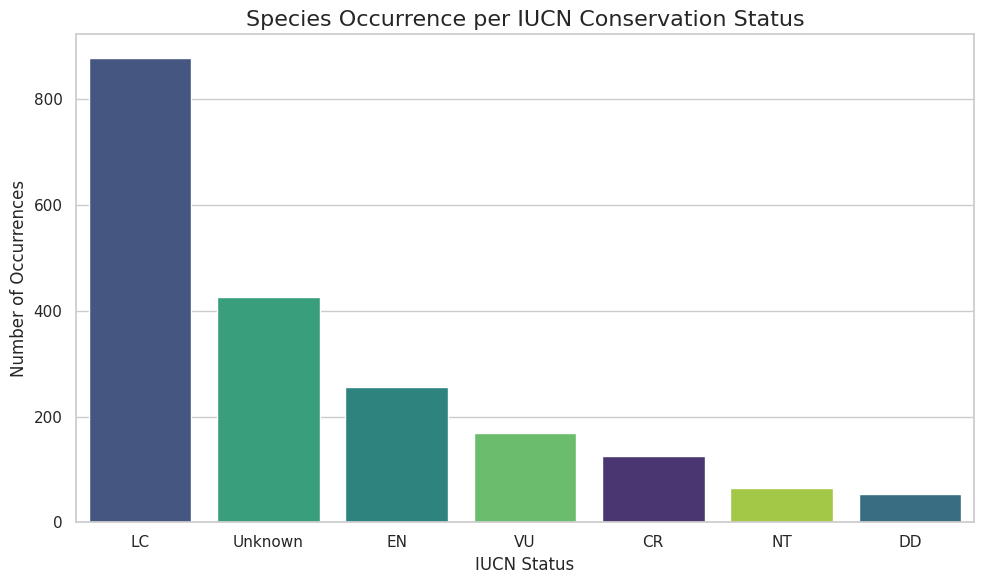

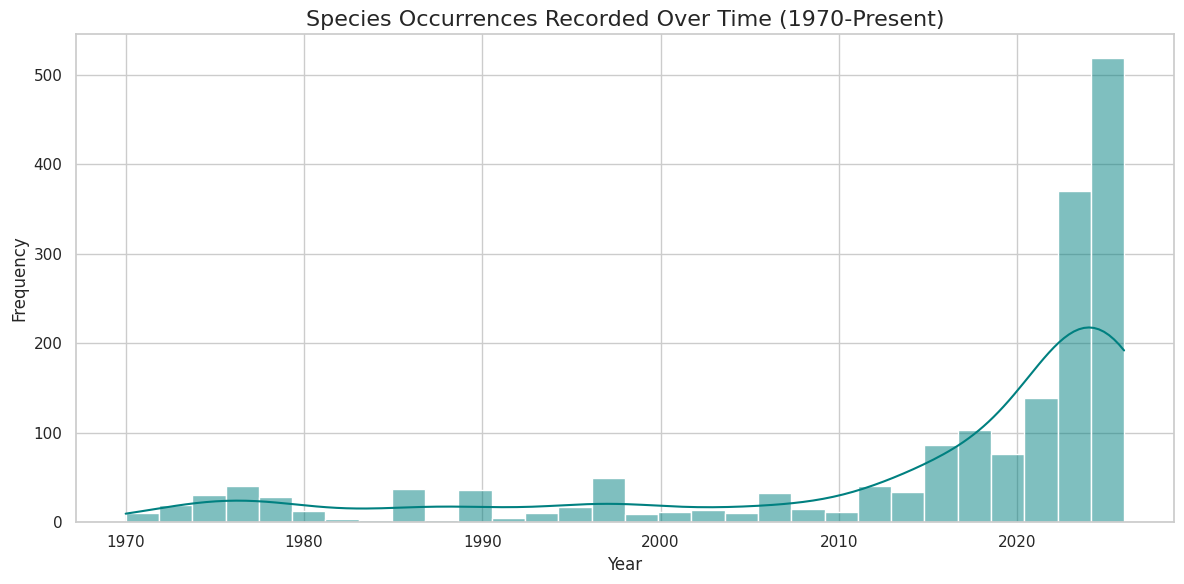

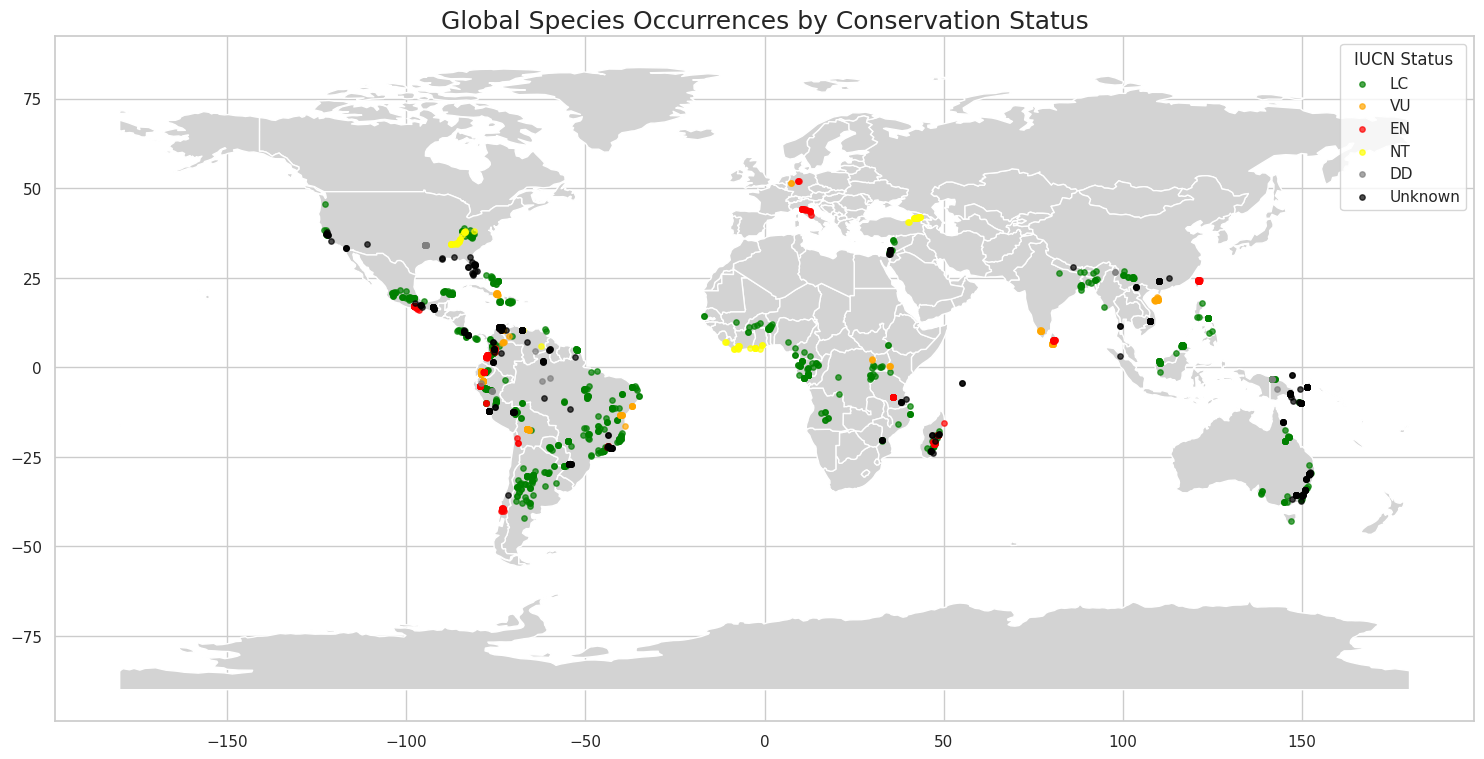

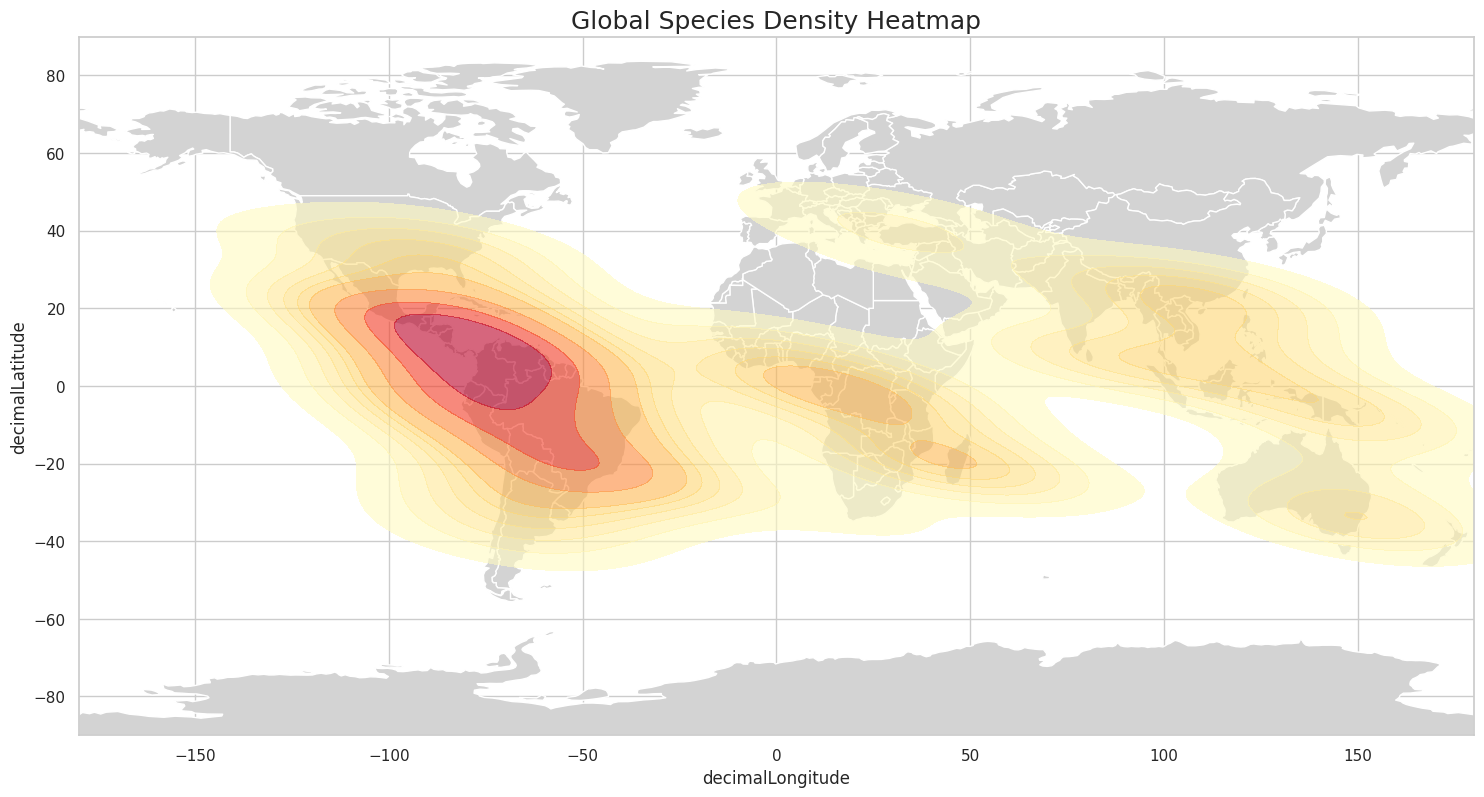

Generating System Architecture Diagram...


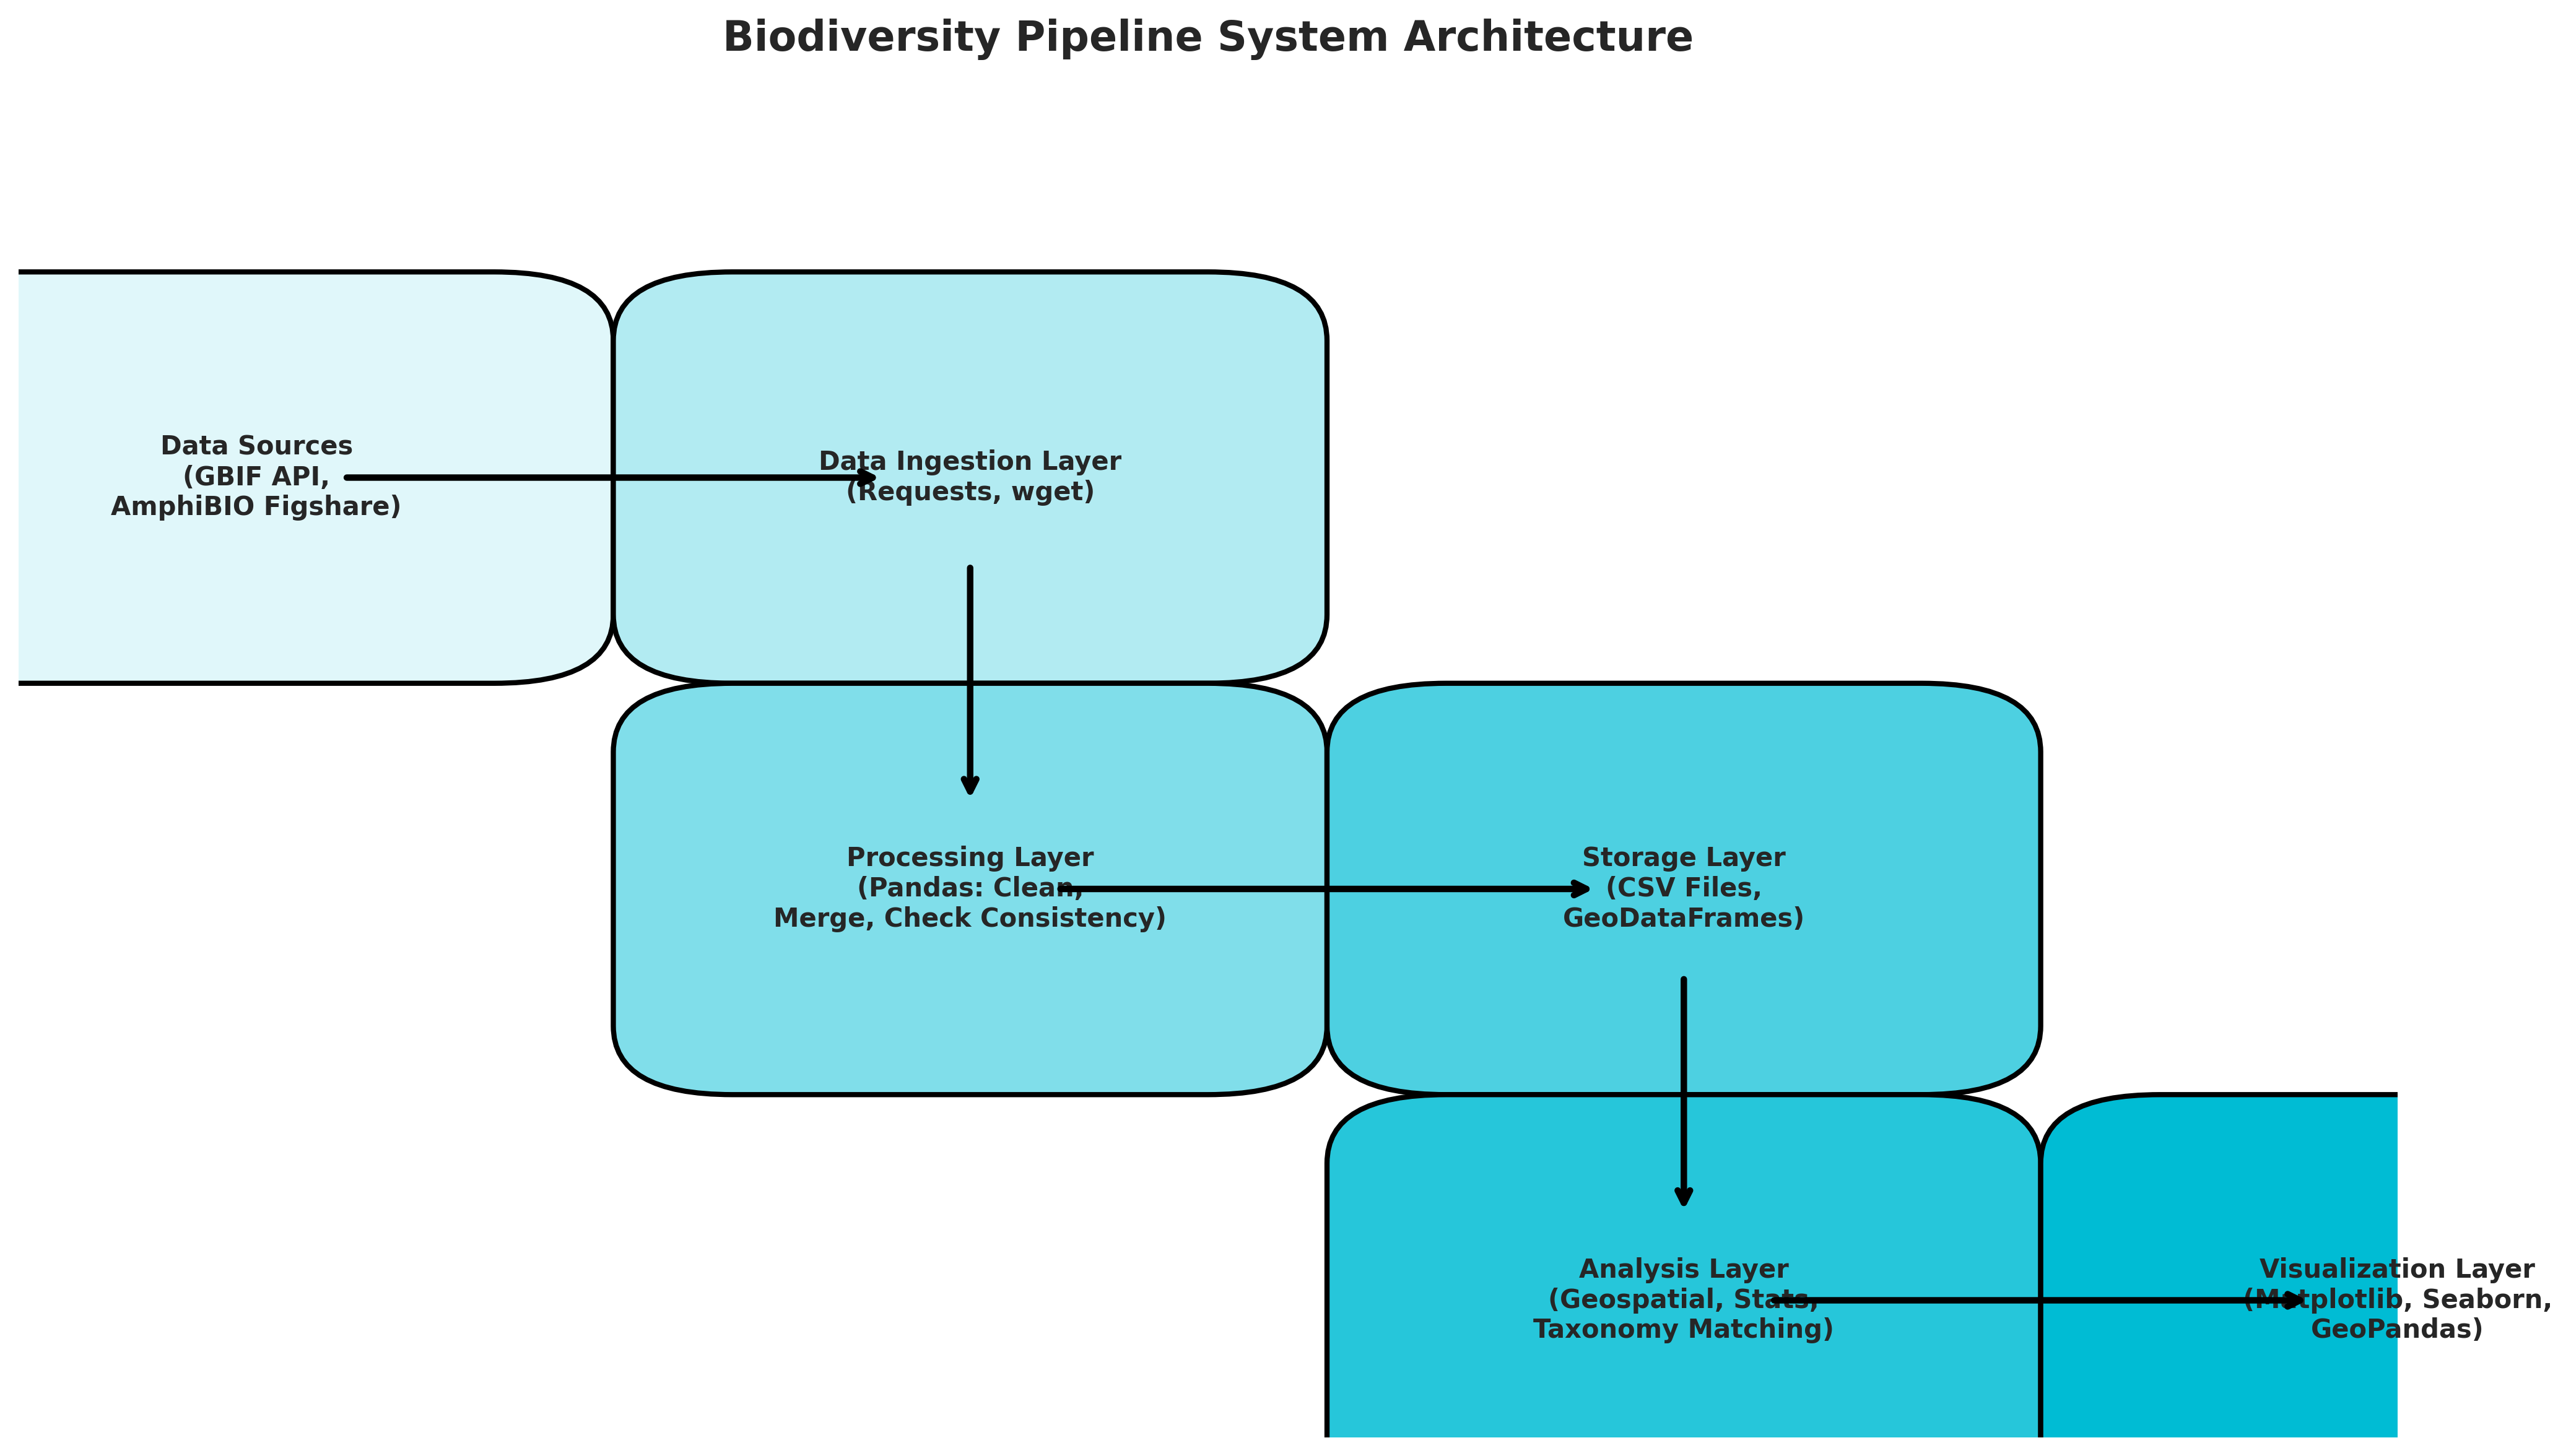

Packaging figures for download...
Not running in Google Colab. The figures are available locally in 'biodiversity_figures.zip'.
Pipeline execution completed successfully.


In [2]:

import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import os
import shutil
from matplotlib.patches import FancyBboxPatch

print("Starting Real-World Biodiversity Analysis Pipeline...")

# --- 1. Data Ingestion & Engineering ---
if not os.path.exists('AmphiBIO_v1.csv'):
    print("Downloading AmphiBIO dataset...")
    os.system('wget -q https://ndownloader.figshare.com/files/8828578 -O amphibio.zip && unzip -o -q amphibio.zip')

print("Loading AmphiBIO dataset...")
amphi_df = pd.read_csv('AmphiBIO_v1.csv', encoding='latin1')
print(f"Loaded {len(amphi_df)} records from AmphiBIO.")

# Perform analysis on a larger subset to capture real-world distribution (using top 150 species to balance API limits and realism)
np.random.seed(42)
sample_species = amphi_df['Species'].dropna().sample(150, random_state=42).tolist()

def fetch_gbif_data(species_list, limit_per_species=20):
    print("Fetching GBIF occurrences and taxonomy...")
    records = []
    consistency_log = []
    
    for species in species_list:
        try:
            match_url = f"https://api.gbif.org/v1/species/match?name={requests.utils.quote(species)}"
            match_res = requests.get(match_url).json()
            
            # Cross-Dataset Consistency Check: Taxonomy mismatch detection
            match_type = match_res.get('matchType', 'NONE')
            if match_type != 'EXACT' and match_type != 'NONE':
                consistency_log.append({
                    'amphibio_name': species,
                    'gbif_accepted_name': match_res.get('scientificName'),
                    'match_type': match_type
                })
                
            if 'usageKey' in match_res:
                taxon_key = match_res['usageKey']
                occ_url = f"https://api.gbif.org/v1/occurrence/search?taxonKey={taxon_key}&limit={limit_per_species}&hasCoordinate=true"
                occ_res = requests.get(occ_url).json()
                
                for res in occ_res.get('results', []):
                    records.append({
                        'species_amphibio': species,
                        'scientific_name': res.get('species'),
                        'decimalLatitude': res.get('decimalLatitude'),
                        'decimalLongitude': res.get('decimalLongitude'),
                        'country': res.get('country'),
                        'year': res.get('year'),
                        'iucn_status': res.get('iucnRedListCategory', 'Unknown')
                    })
        except Exception as e:
            print(f"Error fetching {species}: {e}")
            
    return pd.DataFrame(records), pd.DataFrame(consistency_log)

df_occ, df_consistency = fetch_gbif_data(sample_species)
print(f"Retrieved {len(df_occ)} occurrence records from GBIF.")

if not df_consistency.empty:
    print("\nCross-Dataset Consistency Check (Taxonomy Mismatches):")
    print(df_consistency.head())
    df_consistency.to_csv('taxonomy_consistency_issues.csv', index=False)

# C. Data Cleaning
df_occ = df_occ.dropna(subset=['decimalLatitude', 'decimalLongitude'])

# D. Merge Datasets
df_merged = df_occ.merge(amphi_df[['Species', 'Family', 'Order', 'Body_size_mm']], 
                         left_on='species_amphibio', right_on='Species', how='left')
print("Data ingestion, cleaning, and merging complete.")
df_merged.to_csv('merged_biodiversity_data.csv', index=False)

# --- 2. Analysis & Visualizations ---
print("Generating Visualizations...")
sns.set_theme(style="whitegrid")
os.makedirs("figures", exist_ok=True)

# 1. Bar Chart: Conservation Status Breakdown (Results)
plt.figure(figsize=(10, 6))
sns.countplot(data=df_merged, x='iucn_status', hue='iucn_status', order=df_merged['iucn_status'].value_counts().index, palette="viridis", legend=False)
plt.title("Species Occurrence per IUCN Conservation Status", fontsize=16)
plt.xlabel("IUCN Status", fontsize=12)
plt.ylabel("Number of Occurrences", fontsize=12)
plt.tight_layout()
plt.savefig("figures/conservation_status_bar.png", dpi=300)
plt.show()

# 2. Time-series Plot
recent_years = df_merged[(df_merged['year'] >= 1970) & (df_merged['year'] <= 2026)]
plt.figure(figsize=(12, 6))
sns.histplot(data=recent_years, x='year', bins=30, kde=True, color='teal')
plt.title("Species Occurrences Recorded Over Time (1970-Present)", fontsize=16)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.tight_layout()
plt.savefig("figures/temporal_trends_timeseries.png", dpi=300)
plt.show()

# 3. Geographic Maps (Datasets)
print("Downloading Natural Earth data for maps...")
world_url = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(world_url)
gdf_occ = gpd.GeoDataFrame(df_merged, geometry=gpd.points_from_xy(df_merged.decimalLongitude, df_merged.decimalLatitude), crs="EPSG:4326")

fig, ax = plt.subplots(figsize=(15, 10))
world.plot(ax=ax, color='lightgrey', edgecolor='white')
status_colors = {'LC': 'green', 'VU': 'orange', 'EN': 'red', 'NT': 'yellow', 'DD': 'grey', 'Unknown': 'black'}
for status, color in status_colors.items():
    subset = gdf_occ[gdf_occ['iucn_status'] == status]
    if not subset.empty:
        subset.plot(ax=ax, markersize=15, color=color, label=status, alpha=0.7)
plt.title("Global Species Occurrences by Conservation Status", fontsize=18)
plt.legend(title="IUCN Status")
plt.tight_layout()
plt.savefig("figures/global_species_map.png", dpi=300)
plt.show()

# 4. Heatmap: Species Density (Methods)
fig, ax = plt.subplots(figsize=(15, 10))
world.plot(ax=ax, color='lightgrey', edgecolor='white')
sns.kdeplot(x=df_merged['decimalLongitude'], y=df_merged['decimalLatitude'], fill=True, cmap="YlOrRd", alpha=0.6, ax=ax, thresh=0.05)
plt.title("Global Species Density Heatmap", fontsize=18)
plt.xlim(-180, 180)
plt.ylim(-90, 90)
plt.tight_layout()
plt.savefig("figures/species_density_heatmap.png", dpi=300)
plt.show()

# --- 4. System Architecture Diagram ---
print("Generating System Architecture Diagram...")
def draw_architecture():
    fig, ax = plt.subplots(figsize=(14, 8), dpi=300)
    ax.axis('off')
    nodes = {
        'APIs': {'pos': (0.1, 0.7), 'text': 'Data Sources\n(GBIF API,\nAmphiBIO Figshare)', 'color': '#e0f7fa'},
        'Ingestion': {'pos': (0.4, 0.7), 'text': 'Data Ingestion Layer\n(Requests, wget)', 'color': '#b2ebf2'},
        'ETL': {'pos': (0.4, 0.4), 'text': 'Processing Layer\n(Pandas: Clean,\nMerge, Check Consistency)', 'color': '#80deea'},
        'Storage': {'pos': (0.7, 0.4), 'text': 'Storage Layer\n(CSV Files,\nGeoDataFrames)', 'color': '#4dd0e1'},
        'Analysis': {'pos': (0.7, 0.1), 'text': 'Analysis Layer\n(Geospatial, Stats,\nTaxonomy Matching)', 'color': '#26c6da'},
        'Visualization': {'pos': (1.0, 0.1), 'text': 'Visualization Layer\n(Matplotlib, Seaborn,\nGeoPandas)', 'color': '#00bcd4'}
    }
    for key, info in nodes.items():
        x, y = info['pos']
        box = FancyBboxPatch((x-0.1, y-0.1), 0.2, 0.2, boxstyle="round,pad=0.05", fc=info['color'], ec='black', lw=2)
        ax.add_patch(box)
        ax.text(x, y, info['text'], ha='center', va='center', fontsize=10, fontweight='bold')
    edges = [('APIs', 'Ingestion'), ('Ingestion', 'ETL'), ('ETL', 'Storage'), ('Storage', 'Analysis'), ('Analysis', 'Visualization')]
    for src, dst in edges:
        x1, y1 = nodes[src]['pos']
        x2, y2 = nodes[dst]['pos']
        ax.annotate("", xy=(x2, y2), xytext=(x1, y1), arrowprops=dict(arrowstyle="->", lw=2.5, color='black', shrinkA=35, shrinkB=35))
    plt.title("Biodiversity Pipeline System Architecture", fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig("figures/system_architecture.png", dpi=400)
    plt.show()

draw_architecture()

# --- 5. Package for Download ---
print("Packaging figures for download...")
shutil.make_archive("biodiversity_figures", "zip", "figures")

try:
    from google.colab import files
    print("Downloading figures archive...")
    files.download('biodiversity_figures.zip')
except ImportError:
    print("Not running in Google Colab. The figures are available locally in 'biodiversity_figures.zip'.")

print("Pipeline execution completed successfully.")
